In [35]:
import pandas as pd
from protocols import functions, graphs

from catomatic.BinaryCatalogue import BinaryBuilder

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Workflow used to build catalogues and test their performance 

We use rifampicin as an example. All notebooks in this project follow the same workflow.

## Import Data

In [36]:
# the path to the CRyPTIC v3.4.0 data tables
cryptic_tables_path = 'data/cryptic-tables-v3.4.0/'


In [37]:
#prepare phenotype data
phenotypes = functions.prep_phenotypes('RIF', 
                             cryptic_tables_path+'DST_MEASUREMENTS.parquet', 
                             cryptic_tables_path+'WGS_SAMPLES.parquet', 
                             version='v3.4.0')
phenotypes[:5]

,UNIQUEID,DRUG,PHENOTYPE,METHOD_MIC,METHOD_3
0,site.00.subj.1000347.lab.H111540004.iso.1,RIF,R,None,resistance ratio
1,site.00.subj.1000595.lab.H123460044.iso.1,RIF,R,None,resistance ratio
2,site.00.subj.1004213.lab.H111060034.iso.1,RIF,R,None,resistance ratio
3,site.00.subj.1004213.lab.H112000008.iso.1,RIF,R,None,resistance ratio
4,site.00.subj.1004213.lab.H113100007.iso.1,RIF,R,None,resistance ratio


In [38]:
#prepare mutation data
mutations = functions.prep_mutations('data/mutations-v3.4.0/', 
                           ['rpoB'], 
                           version='v3.4.0', 
                           mut_path=cryptic_tables_path+'MUTATIONS.parquet', 
                           var_path=cryptic_tables_path+'VARIANTS.parquet')
mutations[:5]

,UNIQUEID,MUTATION,FRS,IS_MINOR,MINOR_MUTATION,IS_NULL
0,site.02.subj.0069.lab.22A019.iso.1,rpoB@S450L,1.0,False,NaN,False
4,site.03.subj.6236-05_LIB12062.lab.6236-05_LIB1...,rpoB@S450L,1.0,False,NaN,False
5,site.04.subj.00255.lab.709124.iso.1,rpoB@S450L,1.0,False,NaN,False
8,site.06.subj.RLH_0305-14.lab.06MIL0297.iso.1,rpoB@c-61t,1.0,False,NaN,False
9,site.06.subj.RLH_0305-14.lab.06MIL0297.iso.1,rpoB@S450L,1.0,False,NaN,False


## Use catomatic to build catalogue

In [39]:
catalogue = BinaryBuilder(
                samples=phenotypes, 
                mutations=mutations, 
                FRS=0.1
            )

catalogue.build(test='Binomial', background=0.2, strict_unlock=True, p=0.95)

#conver the catalogue to a pandas dataframe, using a format compatible with piezo
catalogue_df = catalogue.build_piezo(
                    genbank_ref='NC00962.3',
                    catalogue_name='rif_demo', 
                    version='0.0', 
                    drug='RIF', 
                    wildcards="./data/wildcards/rif_wildcards.json", 
                    json_dumps=True
                )

catalogue_df.to_csv('./catalogues/temp/demo_rif_catalogue.csv')

catalogue_df

,GENBANK_REFERENCE,CATALOGUE_NAME,CATALOGUE_VERSION,CATALOGUE_GRAMMAR,PREDICTION_VALUES,DRUG,MUTATION,PREDICTION,SOURCE,EVIDENCE,OTHER
0,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@c-61t,S,{},"{""proportion"": 0.008733624454148471, ""confiden...",{}
1,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@2546_ins_cgagga,S,{},"{""proportion"": 0.0, ""confidence"": [0.0, 0.0675...",{}
2,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@E250G,S,{},"{""proportion"": 0.043010752688172046, ""confiden...",{}
3,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@L449Q,S,{},"{""proportion"": 0.0, ""confidence"": [-6.41460770...",{}
4,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@V695L,S,{},"{""proportion"": 0.05714285714285714, ""confidenc...",{}
...,...,...,...,...,...,...,...,...,...,...,...
411,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@-*_indel,U,{},"{""default_rule"": ""True""}",{}
412,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@*_indel,U,{},"{""default_rule"": ""True""}",{}
413,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@-*?,U,{},"{""default_rule"": ""True""}",{}
414,NC00962.3,rif_demo,0.0,GARC1,RUS,RIF,rpoB@*?,U,{},"{""default_rule"": ""True""}",{}


## Evaluate performance

[[10281   387   260]
 [  367 24732   954]]
Catalogue coverage of isolates: 0.9671723317379195
Sensitivity: 0.9637232845894264
Specificity: 0.9853779035021316


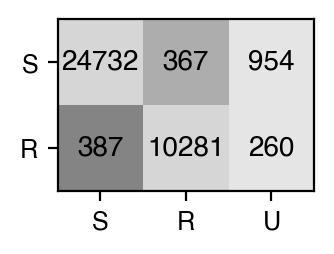

In [40]:
#create a dataset to apply the catalogue to
all = pd.merge(phenotypes, mutations, on=['UNIQUEID'], how='left')

#predict phenotypes for samples in the test set to evaluate catalogue performance
cmatrix = functions.piezo_predict(iso_df=all, drug='RIF', catalogue_file='./catalogues/temp/demo_rif_catalogue.csv', Print=True)[0]

cmatrix= pd.DataFrame(cmatrix, index=["R", "S"], columns=["R", "S", 'U'])

graphs.plot_truthtables(cmatrix, U_to_S=False, save='figs/truthtable-RIF-exemplar.pdf', colors=["#666666", "#cccccc", "#999999", "#cccccc","#cccccc","#cccccc" ])